# F-Praktikum: Quantum Computer Simulation

**Author:** Ayush Singh, Shanidhaya Shashwat 
**Project Goal:** To build a modular, N-qubit quantum circuit simulator from scratch using Python and QuTiP, culminating in the generation and physical analysis of random mixed states based on the Życzkowski et al. paper (arXiv:1010.3570).

## Project Overview
This notebook serves as an interactive interface to the quantum engine developed during this Praktikum. The project is divided into three core physics milestones:
1. **The Circuit Engine:** Parsing and applying continuous parameterized standard and controlled quantum gates to arbitrary $N$-qubit systems.
2. **Measurement Mechanics:** Simulating quantum superposition collapse via projective measurements.
3. **Random State Generation:** Generating and analyzing the geometry of Haar, Hilbert-Schmidt, and Bures random density matrices on the Bloch Sphere.

In [64]:
%load_ext autoreload
%autoreload 2
# --- Setup and Imports ---
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# Ensure plots render directly inside the notebook
%matplotlib inline

# Import our custom modules
from circuit_engine import apply_instruction, measure_qubit
from generator import generate_random_circuit
from visualize import draw_ascii_circuit
from random_states import haar_random_state, hilbert_schmidt_random_state, bures_random_state
from plot_distributions import plot_random_distributions
from plot_purity import plot_purity_distributions
from benchmark_random_states import run_benchmark
from noise_channels import bitflip_channel, amplitude_damping_channel, depolarizing_channel,phaseflip_channel
from deutsch_jozsa import create_dj_oracle,create_dynamic_oracle,indToState
from noise_analysis_dj import plot_custom_noise_analysis,plot_joint_benchmark  
from deutch_jozsa_noisy import run_noisy_dj 
print("Quantum Engine initialized and ready!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Quantum Engine initialized and ready!


## Part 1: Circuit Generation & Visualization
Our engine is capable of automatically generating deeply randomized circuits to scramble quantum information. It selects randomly between single-qubit rotations ($R_x, R_y, R_z$) and multi-qubit entangling gates ($CNOT$, $C-H$, $ISWAP$, etc.).

In [35]:
NUM_QUBITS = 3
NUM_LAYERS = 5

print(f"Generating {NUM_QUBITS}-qubit random circuit with {NUM_LAYERS} layers...")
ops, descs, instrs = generate_random_circuit(NUM_QUBITS, NUM_LAYERS)

# Draw the resulting circuit using our ASCII visualizer
draw_ascii_circuit(NUM_QUBITS, instrs)

Generating 3-qubit random circuit with 5 layers...

=== Generated Quantum Circuit ===
q0: ────[H]──────[X]─────[Ry]─────[Ry]──────[X]────
q1: ─────│───────[X]──────[S]──────[T]──────[S]────
q2: ─────■──────[Ry]──────[X]──────[H]──────[X]────



## Part 2: Wavefunction Evolution & Measurement
We can apply the generated circuit to a baseline $|00...0\rangle$ state. Following standard quantum mechanics, applying projective measurement $P_m$ to a specific qubit collapses the system into a definite state with probability $p = \text{Tr}(P_m \rho)$.

In [36]:
# 1. Initialize |000>
state = qt.tensor([qt.basis(2, 0)] * NUM_QUBITS)

# 2. Evolve the state through the random circuit
for op in ops:
    state = op * state
    
print("State evolved successfully.")
print(f"Final State Purity before measurement: {(state * state.dag()).tr().real:.4f}")

# 3. Measure Qubit 0
target_q = 0
print(f"\n--- Measuring Qubit {target_q} ---")
result, collapsed_state = measure_qubit(state, target_q)

print(f"Classical Result: {result}")
print("System successfully collapsed to reflect the measurement!")

State evolved successfully.
Final State Purity before measurement: 1.0000

--- Measuring Qubit 0 ---
Classical Result: 1
System successfully collapsed to reflect the measurement!


## Part 3: Random Density Matrices (arXiv:1010.3570)
To simulate open quantum systems interacting with an environment, we generate random mixed states using complex Ginibre matrices ($G$). According to the literature, we can generate three distinct ensembles:

1. **Haar States:** Pure states generated by uniform unitaries. $\rho = |\psi\rangle\langle\psi|$
2. **Hilbert-Schmidt (HS) States:** Created by mathematically tracing out an environment of equal dimension. $\rho \propto G G^\dagger$
3. **Bures States:** A mixed ensemble generated via rejection-sampled unitaries, biasing the states toward the pure boundary. $\rho \propto (I+U)GG^\dagger(I+U^\dagger)$

In [37]:
# Generate one of each state to verify QuTiP matrix properties
rho_haar = haar_random_state(2)
rho_hs = hilbert_schmidt_random_state(2)
rho_bures = bures_random_state(2)
print("haar random state",rho_haar)
print("hilbert schmidt random state",rho_hs)
print("bures random state",rho_bures)
print("Haar Purity (Expected 1.0):", (rho_haar**2).tr().real)
print("HS Purity (Expected ~0.80):", (rho_hs**2).tr().real)
print("Bures Purity (Expected ~0.87):", (rho_bures**2).tr().real)

haar random state Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.48357488+0.j         -0.24546917-0.43528738j]
 [-0.24546917+0.43528738j  0.51642512+0.j        ]]
hilbert schmidt random state Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.6495913 +0.j         0.03176217-0.03768826j]
 [0.03176217+0.03768826j 0.3504087 +0.j        ]]
bures random state Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.25650845+2.00752281e-17j 0.29011357+2.34827227e-01j]
 [0.29011357-2.34827227e-01j 0.74349155-5.01880703e-17j]]
Haar Purity (Expected 1.0): 0.9999999999999998
HS Purity (Expected ~0.80): 0.5496135962454771
Bures Purity (Expected ~0.87): 0.8971956857395813


### 3.1 Visualizing Geometries on the Bloch Sphere
Because random matrices are hard to interpret numerically, we map hundreds of samples to the $X, Y, Z$ coordinates of the Bloch Sphere using the Pauli expectation values: $x = \text{Tr}(\sigma_x \rho)$.

*Note: This will pop open a matplotlib window to render the 3D graphics.*

Generating 500 states for each distribution. Please wait...
Rendering complete!


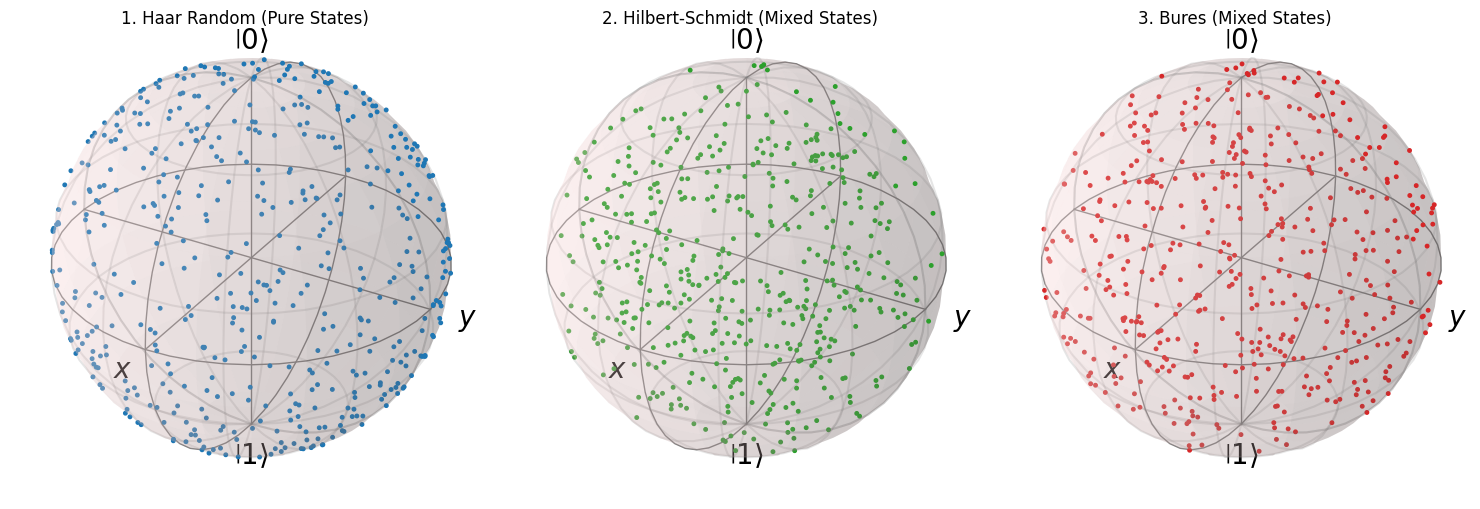

In [38]:
# Renders 500 points for each distribution on 3 side-by-side Bloch spheres
plot_random_distributions(num_samples=500)

### 3.2 Purity Histograms
To rigorously prove the visual geometries above, we calculate the purity $\text{Tr}(\rho^2)$ of 10,000 generated states and plot their probability densities.
- **Haar** must spike at $1.0$.
- **HS** must uniformly fill the volume down to $0.5$.
- **Bures** must heavily bias towards the $1.0$ surface.

Generating 10000 states for each distribution. This may take a moment...
Mean HS Purity: 0.8018 (Theoretical: 0.8000)
Mean Bures Purity: 0.8756 (Theoretical: 0.8750)
Done! Displaying plot...


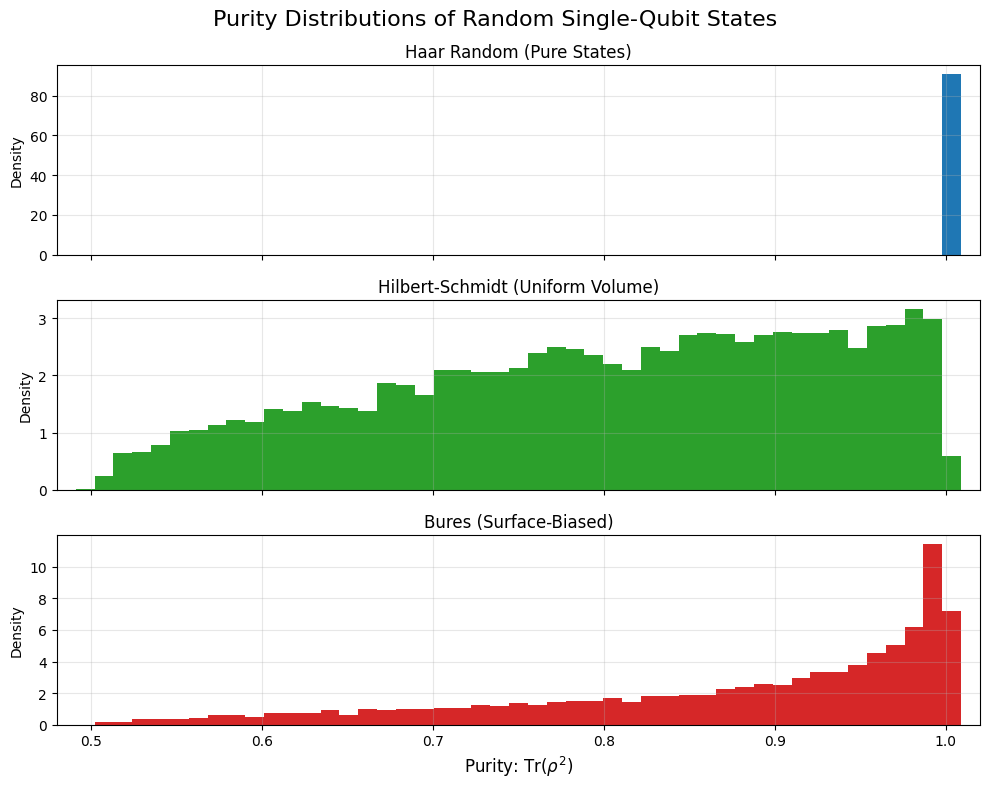

In [39]:
# Generates 10,000 states and plots the mathematical purity distributions
plot_purity_distributions(num_samples=10000)

##  Part 4: Physical vs. Mathematical Benchmarking
Why do we use the mathematical Ginibre matrix equations above instead of just physically simulating a random circuit and tracing out an environment every time? 
The benchmark below proves the exponential performance cost of simulating the environment physically.

System Qubits   | Circuit Time (s)     | Math Time (s)  
-------------------------------------------------------
1               | 0.1183               | 0.000479       
2               | 0.2013               | 0.000348       
3               | 0.1961               | 0.000236       
4               | 0.2918               | 0.000268       

Benchmark complete! Rendering plot...


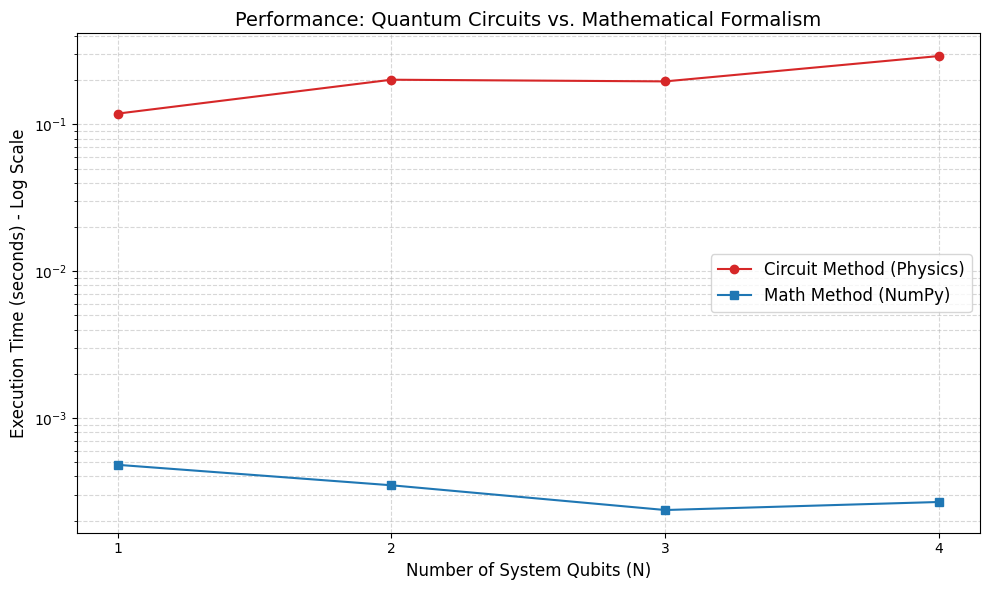

In [40]:
# Runs the benchmark comparing Circuit Evolution vs. NumPy Matrix generation
run_benchmark()

---
## Part 5: Quantum Noise Channels (Open Systems)
Real quantum computers suffer from decoherence. We implemented Kraus Operators to mathematically pull pure states off the surface of the Bloch sphere and into the mixed interior.

In [41]:
# Create a perfect |+> pure state
psi_plus = (qt.basis(2, 0) + qt.basis(2, 1)).unit()
rho_pure = psi_plus * psi_plus.dag()

print(f"Initial Purity: {rho_pure.purity():.4f}")

# Apply 40% Amplitude Damping (Energy Loss)
rho_damped = amplitude_damping_channel(rho_pure, gamma=0.4, target=0)
print(f"Purity after Amplitude Damping: {rho_damped.purity():.4f}")

# Apply 50% Global Depolarizing Noise
rho_depol = depolarizing_channel(rho_pure, p=0.5)
print(f"Purity after 50% Depolarizing Noise: {rho_depol.purity():.4f}")

Initial Purity: 1.0000
Purity after Amplitude Damping: 0.8800
Purity after 50% Depolarizing Noise: 0.6250


---
## Part 6: The Deutsch-Jozsa Algorithm
Proving Quantum Advantage: This algorithm evaluates an $N$-bit secret Blackbox (Oracle) function. A classical computer requires $2^{N-1}+1$ queries to determine if the function is Constant or Balanced. Our quantum simulator does it in **exactly 1 query** using superposition and quantum interference.

In [42]:
def execute_dj(num_qubits, oracle_type):
    state = qt.tensor([qt.basis(2, 0)] * num_qubits)
    
    # 1. Total Superposition
    for q in range(num_qubits):
        state = apply_instruction(state, ['H', [q]])
        
    # 2. Apply the dynamic Oracle (Phase Kickback)
    U_f = create_dj_oracle(num_qubits, oracle_type)
    state = U_f * state
    
    # 3. Interference
    for q in range(num_qubits):
        state = apply_instruction(state, ['H', [q]])
        
    # 4. Measure
    measurements = [measure_qubit(state, target_qubit=q)[0] for q in range(num_qubits)]
    
    conclusion = "CONSTANT" if sum(measurements) == 0 else "BALANCED"
    print(f"Oracle: {oracle_type.ljust(25)} -> Measured {measurements} -> {conclusion}")

print("Executing 3-Qubit Deutsch-Jozsa:\n")
execute_dj(3, "constant_1")
execute_dj(3, "balanced")
execute_dj(3, "balanced_first_qubit")

Executing 3-Qubit Deutsch-Jozsa:

Oracle: constant_1                -> Measured [0, 0, 0] -> CONSTANT
Oracle: balanced                  -> Measured [1, 1, 1] -> BALANCED
Oracle: balanced_first_qubit      -> Measured [1, 0, 0] -> BALANCED


### Import any Black Box

In [43]:
from black_box import black_box

In [44]:
def execute_dynamic_dj(num_qubits, func):
    """Executes the Deutsch-Jozsa algorithm using a real Python blackbox function!"""
    state = qt.tensor([qt.basis(2, 0)] * num_qubits)
    
    # 1. Total Superposition
    for q in range(num_qubits):
        state = apply_instruction(state, ['H', [q]])
        
    # 2. Apply the dynamic Oracle (Translates the Python func into a Matrix)
    U_f = create_dynamic_oracle(num_qubits, func)
    state = U_f * state
    
    # 3. Interference
    for q in range(num_qubits):
        state = apply_instruction(state, ['H', [q]])
        
    # 4. Measure
    measurements = [measure_qubit(state, target_qubit=q)[0] for q in range(num_qubits)]
    
    # 5. Conclusion
    conclusion = "CONSTANT" if sum(measurements) == 0 else "BALANCED"
    print(f"Mystery Blackbox (n={num_qubits}) -> Measured {measurements} -> {conclusion}")

In [45]:
print("Checking the Mystery Blackbox...")
execute_dynamic_dj(1, black_box)
execute_dynamic_dj(2, black_box)
execute_dynamic_dj(3, black_box)
execute_dynamic_dj(4, black_box)
execute_dynamic_dj(5, black_box)
execute_dynamic_dj(6, black_box)

Checking the Mystery Blackbox...
Mystery Blackbox (n=1) -> Measured [1] -> BALANCED
Mystery Blackbox (n=2) -> Measured [0, 1] -> BALANCED
Mystery Blackbox (n=3) -> Measured [0, 0, 0] -> CONSTANT
Mystery Blackbox (n=4) -> Measured [0, 0, 1, 0] -> BALANCED
Mystery Blackbox (n=5) -> Measured [0, 0, 0, 0, 0] -> CONSTANT
Mystery Blackbox (n=6) -> Measured [0, 0, 0, 0, 0, 0] -> CONSTANT


### Classical Check

In [46]:
def classical_check(n: int):
    dim = 2 ** n
    outputs = []
    
    print(f"\nClassical Check for n={n}:")
    for k in range(dim):
        bit_string = indToState(n, k)
        result = black_box(bit_string)
        outputs.append(result)
        
    if all(x == 0 for x in outputs) or all(x == 1 for x in outputs):
        print(f"Classical Conclusion: CONSTANT. (Looked at all {dim} outputs: {outputs})")
    else:
        print(f"Classical Conclusion: BALANCED. (Looked at all {dim} outputs: {outputs})")

for n in range(1, 7):
    classical_check(n)


Classical Check for n=1:
Classical Conclusion: BALANCED. (Looked at all 2 outputs: [0, 1])

Classical Check for n=2:
Classical Conclusion: BALANCED. (Looked at all 4 outputs: [0, 1, 0, 1])

Classical Check for n=3:
Classical Conclusion: CONSTANT. (Looked at all 8 outputs: [0, 0, 0, 0, 0, 0, 0, 0])

Classical Check for n=4:
Classical Conclusion: BALANCED. (Looked at all 16 outputs: [0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1])

Classical Check for n=5:
Classical Conclusion: CONSTANT. (Looked at all 32 outputs: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Classical Check for n=6:
Classical Conclusion: CONSTANT. (Looked at all 64 outputs: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


### Compiling Classical Functions into Quantum Oracles

In [47]:
from black_box import black_box

In [48]:
n = 3
print(f"--- Explicit Circuit Construction (n={n}) ---")

# 1. Initialize
state = qt.tensor([qt.basis(2, 0)] * n)

# 2. Superposition
for q in range(n):
    state = apply_instruction(state, ['H', [q]])

# 3. Dynamic Oracle Compilation
print("Compiling classical 'black_box.py' into Quantum Oracle...")
U_f = create_dynamic_oracle(n, black_box)
state = U_f * state

# 4. Final Interference
for q in range(n):
    state = apply_instruction(state, ['H', [q]])

# 5. Measure
measurements = []
for q in range(n):
    result, state = measure_qubit(state, target_qubit=q)
    measurements.append(result)

if sum(measurements) == 0:
    print(f"Conclusion: CONSTANT. Final State Collapsed to {measurements}")
else:
    print(f"Conclusion: BALANCED. Final State Collapsed to {measurements}")

--- Explicit Circuit Construction (n=3) ---
Compiling classical 'black_box.py' into Quantum Oracle...
Conclusion: CONSTANT. Final State Collapsed to [0, 0, 0]


---
### Verification: Vector vs. Density Matrix Evolution

To verify that our new Density Matrix engine behaves identically to our original State Vector engine in a noiseless environment ($p=0.0$). 

The following test executes the Deutsch-Jozsa algorithm using both mathematical frameworks:
1. **Schrödinger Picture:** Tracking the pure state vector $|\psi\rangle$.
2. **von Neumann Picture:** Tracking the outer product density matrix $\rho = |\psi\rangle\langle\psi|$.

By comparing the final probability of measuring the $|000\rangle$ state, we mathematically prove that our new $U \rho U^\dagger$ evolution logic is correct.

In [49]:
print("--- VERIFICATION: VECTOR VS DENSITY MATRIX ---")
n = 3
oracle = "constant_0"

# 1. Run Old Vector Method (Recreated directly to avoid import/measurement issues)
state_vector = qt.tensor([qt.basis(2, 0)] * n)

# Superposition
for q in range(n):
    state_vector = apply_instruction(state_vector, ['H', [q]])
    
# Oracle
U_f = create_dj_oracle(n, oracle)
state_vector = U_f * state_vector

# Interference
for q in range(n):
    state_vector = apply_instruction(state_vector, ['H', [q]])

# Extract the probability of the |000> state BEFORE any measurement collapse happens
prob_vector = np.abs(state_vector.full()[0][0])**2 

# 2. Run New Density Matrix Method (p=0.0 noise)
prob_density = run_noisy_dj(n, oracle, noise_prob=0.0)

print(f"Vector Probability of |000>        : {prob_vector:.5f}")
print(f"Density Matrix Probability of |000>: {prob_density:.5f}")

if np.isclose(prob_vector, prob_density):
    print("SUCCESS: Both mathematical approaches yield identical results!")
else:
    print("WARNING: Results do not match.")

--- VERIFICATION: VECTOR VS DENSITY MATRIX ---
Vector Probability of |000>        : 1.00000
Density Matrix Probability of |000>: 1.00000
SUCCESS: Both mathematical approaches yield identical results!


---
### Step-by-Step Experiment: Evaluating Quantum Fault Tolerance

To rigorously test the physical resilience of the Deutsch-Jozsa algorithm, we configure a custom parameter sweep. We will evaluate three distinct scenarios to observe how the *type* and *location* of environmental noise dictate algorithmic failure:

1. **Phase Flip AFTER the Oracle (Constant, $N=3$):** Tests the extreme fragility of the relative phases required for quantum interference.
2. **Bit Flip AFTER the Oracle (Constant, $N=3$):** Tests the natural immunity of the superposition $|+\rangle$ state to Pauli-X errors.
3. **Bit Flip BEFORE the Oracle (Balanced, $N=4$):** Tests how classical input corruption prior to the Oracle's phase-kickback completely reverses the quantum evaluation.

By utilizing our generalized testing framework (`noise_analysis_dj.py`), we dynamically compile these density matrices and plot their accuracy decay curves simultaneously.

In [59]:
# --- STEP 1: Define the Experiments ---
# We configure three specific test cases to evaluate algorithmic fault tolerance.
my_experiments = [
    # Constant Functions (Testing N=3 and N=5)
    # Notice we changed 'after' to 'post_oracle' here!
    {'n': 3, 'oracle': 'constant_0', 'channel': phaseflip_channel, 'location': 'post_oracle', 'label': 'Phase Flip AFTER Oracle (Constant N=3)', 'color': 'lightcoral', 'marker': 'o'},
    {'n': 5, 'oracle': 'constant_0', 'channel': phaseflip_channel, 'location': 'post_oracle', 'label': 'Phase Flip AFTER Oracle (Constant N=5)', 'color': 'darkred', 'marker': 'o'},
    
    # Balanced Functions (Testing N=4 and N=6)
    # Notice we changed 'before' to 'post_H1' here!
    {'n': 4, 'oracle': 'balanced', 'channel': bitflip_channel, 'location': 'post_H1', 'label': 'Bit Flip BEFORE Oracle (Balanced N=4)', 'color': 'lightgreen', 'marker': '^'},
    {'n': 6, 'oracle': 'balanced', 'channel': bitflip_channel, 'location': 'post_H1', 'label': 'Bit Flip BEFORE Oracle (Balanced N=6)', 'color': 'darkgreen', 'marker': '^'}
]


Executing Custom Experiment Sweeps. Compiling density matrices...


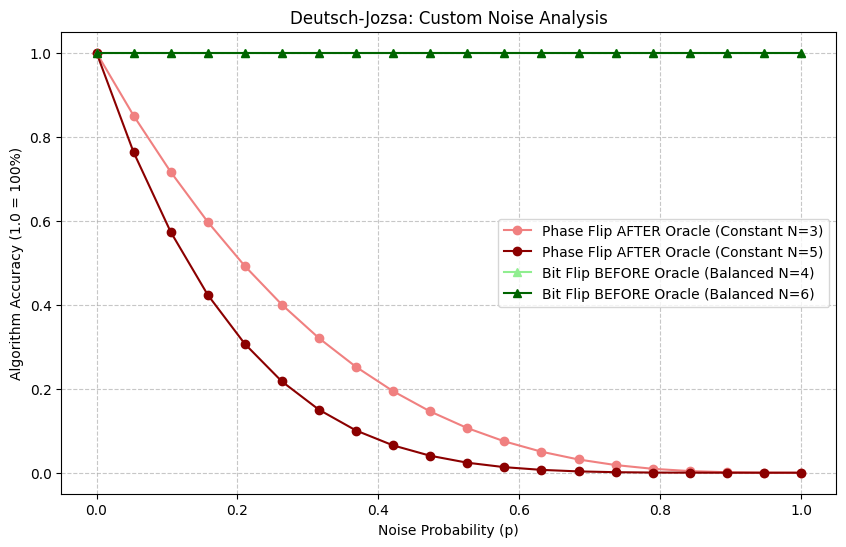

In [60]:
# --- STEP 2: Execute the Sweeps ---
print("Executing Custom Experiment Sweeps. Compiling density matrices...")
plot_custom_noise_analysis(my_experiments, num_points=20)

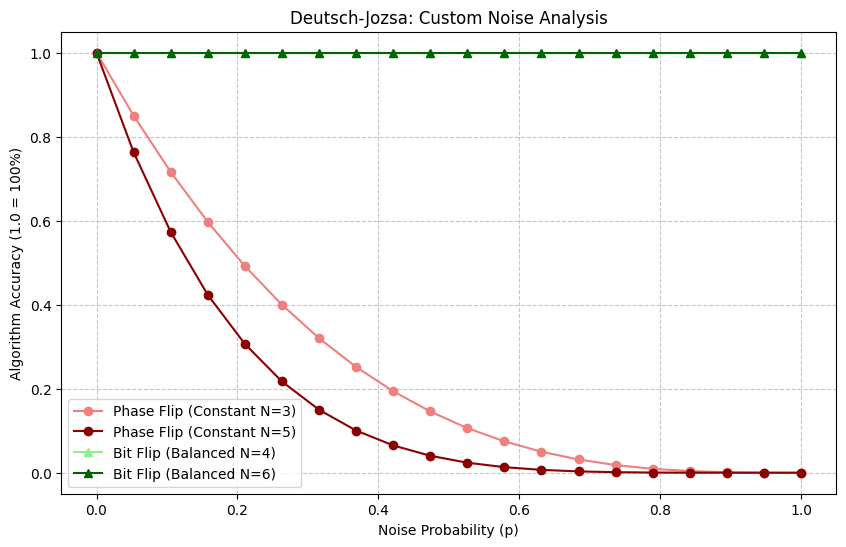

In [ ]:
# --- STEP: Execute the Updated Sweeps ---
# We must use the new precise keywords: 'pre_H1', 'post_H1', 'post_oracle', 'post_H2'

my_experiments = [
    # Constant Functions (Testing N=3 and N=5)
    {'n': 3, 'oracle': 'constant_0', 'channel': phaseflip_channel, 'location': 'post_oracle', 'label': 'Phase Flip (Constant N=3)', 'color': 'lightcoral', 'marker': 'o'},
    {'n': 5, 'oracle': 'constant_0', 'channel': phaseflip_channel, 'location': 'post_oracle', 'label': 'Phase Flip (Constant N=5)', 'color': 'darkred', 'marker': 'o'},
    
    # Balanced Functions (Testing N=4 and N=6)

    {'n': 4, 'oracle': 'balanced', 'channel': bitflip_channel, 'location': 'post_H1', 'label': 'Bit Flip (Balanced N=4)', 'color': 'lightgreen', 'marker': '^'},
    {'n': 6, 'oracle': 'balanced', 'channel': bitflip_channel, 'location': 'post_H1', 'label': 'Bit Flip (Balanced N=6)', 'color': 'darkgreen', 'marker': '^'}
]

# This will now trigger the actual noise logic in the physics engine
plot_custom_noise_analysis(my_experiments, num_points=20)

---
### Noise Vulnerability Analysis Table
The theoretical vulnerability of the DJ Algorithm under Bitflip ($X$) and Phaseflip ($Z$) errors at the four distinct circuit locations.

| Location | Error | Constant Function | Balanced Function | Reason |
| :--- | :--- | :--- | :--- | :--- |
| **pre_H1** | Bitflip ($X$) | **Fails** | **Fails** | Flips input |0\rangle \to |1\rangle$, altering the basis entirely. |
| **pre_H1** | Phaseflip ($Z$) | **Immune** | **Immune** | $Z\|0\rangle = \|0\rangle$. The state is mathematically immune. |
| **post_H1** | Bitflip ($X$) | **Immune** | **Immune** | $X\|+\rangle = \|+\rangle$. The superposition is immune to X. |
| **post_H1** | Phaseflip ($Z$) | **Fails** | **Fails** | $Z\|+\rangle = \|-\rangle$. Destroys the relative phases before the Oracle. |
| **post_oracle** | Bitflip ($X$) | **Immune** | **Immune** | State is still in the $X$-eigenbasis. |
| **post_oracle** | Phaseflip ($Z$) | **Fails** | **Fails** | Reverses the phase kickback applied by the Oracle. |
| **post_H2** | Bitflip ($X$) | **Fails** | **Fails** | Directly flips the final measurement basis |000\rangle \to |100\rangle$). |
| **post_H2** | Phaseflip ($Z$) | **Immune** | **Immune** | $Z$ applies a $-1$ phase but does not change the measurement probability. |

--- Joint Benchmark: Noise Post-H1 ---


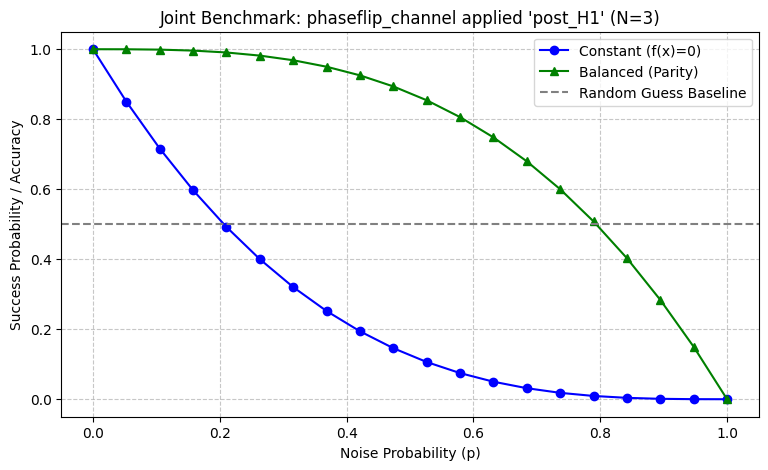

--- Joint Benchmark: Global Depolarizing ---


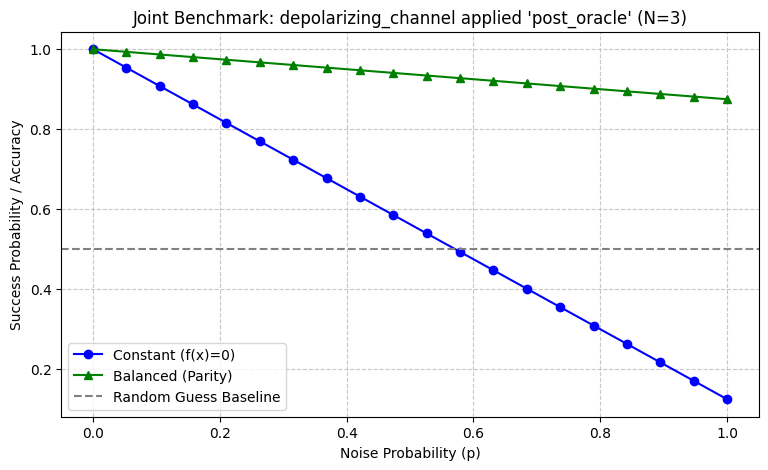

--- Noise Cancellation Experiment ---


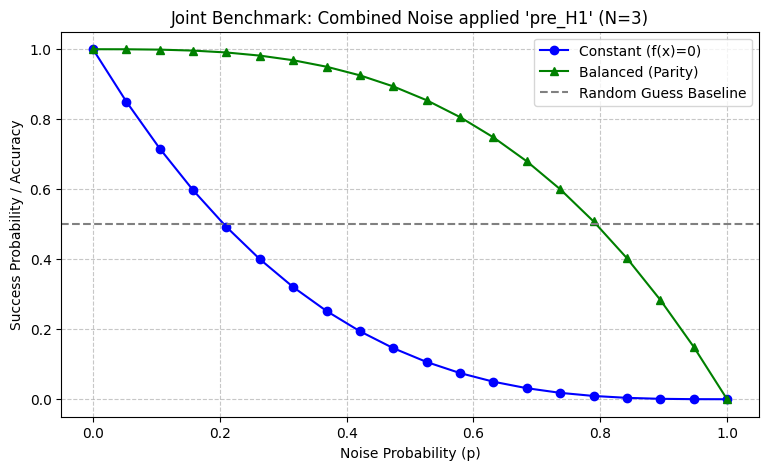

In [65]:


print("--- Joint Benchmark: Noise Post-H1 ---")
# Task 2 & 3: Joint plot for Constant and Balanced, tested post_H1
plot_joint_benchmark(n=3, channel=phaseflip_channel, loc="post_H1")

print("--- Joint Benchmark: Global Depolarizing ---")
# Task 1: Proving Depolarizing channel compatibility
plot_joint_benchmark(n=3, channel=depolarizing_channel, loc="post_oracle")

print("--- Noise Cancellation Experiment ---")
# Task 5: What happens if we apply BOTH Bitflip and Phaseflip?
# Due to the helper function upgrade, we can now pass a LIST of channels!
plot_joint_benchmark(n=3, channel=[bitflip_channel, phaseflip_channel], loc="pre_H1")

Generating the comprehensive 12-combination benchmark grid...


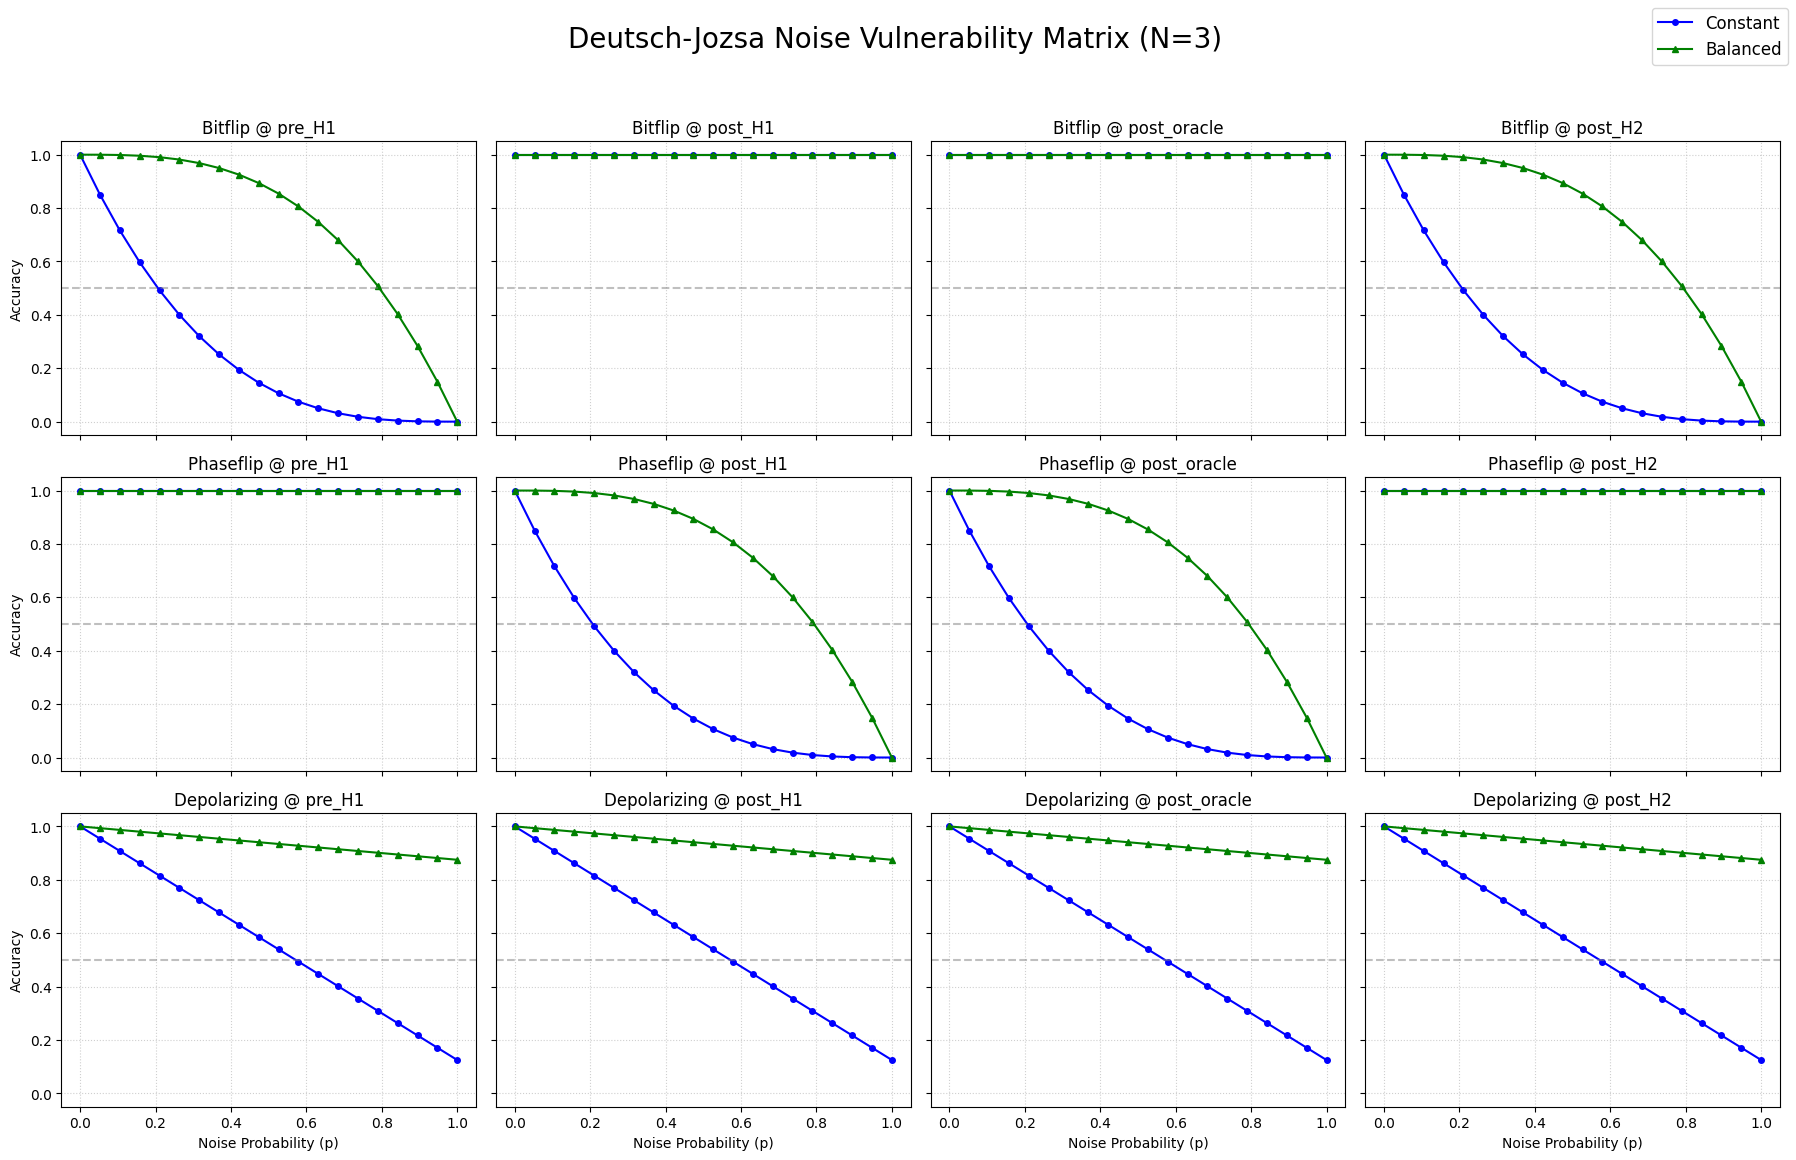

In [63]:
from noise_analysis_dj import plot_all_combinations

print("Generating the comprehensive 12-combination benchmark grid...")
plot_all_combinations(n=3, num_points=20)